In [543]:
#import
import os
from dotenv import load_dotenv
from huggingface_hub import login
from datasets import load_dataset, Dataset, DatasetDict
import matplotlib.pyplot as plt
%matplotlib inline

In [544]:
# environment
load_dotenv(override=True)

# Get the HF token from environment variables
hf_token = os.getenv('HF_TOKEN')

# Log in to Hugging face
login(hf_token, add_to_git_credential=True)

In [545]:
# Load in our dataset
rawdata = load_dataset("5CD-AI/Vietnamese-Multi-turn-Chat-Alpaca", split="train")

# Data Exploration

In [546]:
len(rawdata)

12697

In [547]:
print(rawdata[0])

{'conversations': [{'from': 'human', 'value': 'Hãy chỉnh sửa câu này để ngắn gọn hơn mà không mất đi ý nghĩa: "Trận đấu là một thất bại nặng nề mặc dù thực tế là cả đội đã tập luyện trong nhiều tuần."'}, {'from': 'gpt', 'value': 'Nhiều tuần huấn luyện của đội đã dẫn đến một thất bại nặng nề.'}, {'from': 'human', 'value': 'Bạn có thể đề xuất một số chiến lược mà nhóm có thể sử dụng để cải thiện hiệu suất của họ trong trận đấu tiếp theo không?'}, {'from': 'gpt', 'value': 'Chắc chắn, đây là một số chiến lược mà nhóm có thể sử dụng để cải thiện hiệu suất của mình trong trận đấu tiếp theo: 1. Phân tích trận đấu trước bằng cách xem lại cảnh quay trận đấu để xác định điểm yếu và các lĩnh vực cần cải thiện. 2. Tăng cường độ và sự tập trung của các buổi tập để đảm bảo mọi cầu thủ đều được chuẩn bị đầy đủ về thể chất và tinh thần. 3. Luyện tập những kỹ năng cụ thể cần cải thiện, chẳng hạn như sút bóng hoặc chuyền bóng chính xác. 4. Phát triển các chiến lược và chiến thuật của đội có tính đến điể

In [548]:
# Investigate a particular datapoint
datapoint = rawdata[1]
datapoint

{'conversations': [{'from': 'human',
   'value': 'Tạo một câu hỏi bằng tiếng Anh liên quan đến chủ đề đã cho: Biến đổi khí hậu'},
  {'from': 'gpt', 'value': 'Nguyên nhân của biến đổi khí hậu là gì?'},
  {'from': 'human',
   'value': 'Làm thế nào chúng ta có thể giảm lượng khí thải carbon để chống lại biến đổi khí hậu?'},
  {'from': 'gpt',
   'value': 'Những tác động lâu dài tiềm tàng của biến đổi khí hậu trên hành tinh của chúng ta là gì?'},
  {'from': 'human',
   'value': 'Có giải pháp nào được các nhà khoa học đề xuất để giảm thiểu những tác động đó không?'},
  {'from': 'gpt',
   'value': 'Chính phủ có thể thực hiện những chính sách hoặc hành động nào để giải quyết và giảm thiểu tác động của biến đổi khí hậu?'},
  {'from': 'human',
   'value': 'Một số ví dụ về các chính sách hoặc hành động biến đổi khí hậu thành công đã được các chính phủ thực hiện là gì?'},
  {'from': 'gpt',
   'value': 'Biến đổi khí hậu ảnh hưởng đến đa dạng sinh học của hành tinh như thế nào và có thể làm gì để bả

In [549]:
datapoint = rawdata[1]
print(datapoint['conversations'])

[{'from': 'human', 'value': 'Tạo một câu hỏi bằng tiếng Anh liên quan đến chủ đề đã cho: Biến đổi khí hậu'}, {'from': 'gpt', 'value': 'Nguyên nhân của biến đổi khí hậu là gì?'}, {'from': 'human', 'value': 'Làm thế nào chúng ta có thể giảm lượng khí thải carbon để chống lại biến đổi khí hậu?'}, {'from': 'gpt', 'value': 'Những tác động lâu dài tiềm tàng của biến đổi khí hậu trên hành tinh của chúng ta là gì?'}, {'from': 'human', 'value': 'Có giải pháp nào được các nhà khoa học đề xuất để giảm thiểu những tác động đó không?'}, {'from': 'gpt', 'value': 'Chính phủ có thể thực hiện những chính sách hoặc hành động nào để giải quyết và giảm thiểu tác động của biến đổi khí hậu?'}, {'from': 'human', 'value': 'Một số ví dụ về các chính sách hoặc hành động biến đổi khí hậu thành công đã được các chính phủ thực hiện là gì?'}, {'from': 'gpt', 'value': 'Biến đổi khí hậu ảnh hưởng đến đa dạng sinh học của hành tinh như thế nào và có thể làm gì để bảo tồn nó?'}, {'from': 'human', 'value': 'Có loài hoặc

In [550]:
count = 0
total = len(rawdata)

for datapoint in rawdata:
    try:
        convs = datapoint["conversations"]
        if convs and len(convs) > 0:   # check list có phần tử
            count += 1
    except KeyError:
        pass

print(f"Found {count} / {total} datapoints with conversations ({count/total*100:.1f}%)")

Found 12697 / 12697 datapoints with conversations (100.0%)


In [551]:
lengths = []

for datapoint in rawdata:
    convs = datapoint["conversations"]
    text = "\n".join([turn["value"] for turn in convs])
    lengths.append(len(text))  # số ký tự


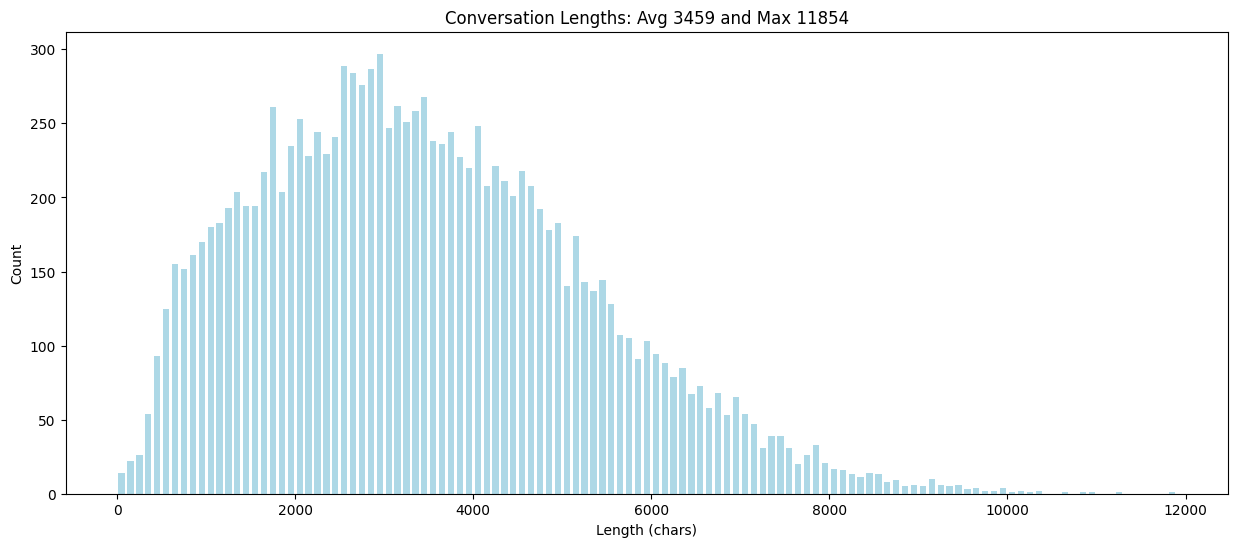

In [552]:
plt.figure(figsize=(15, 6))
plt.title(
    f"Conversation Lengths: "
    f"Avg {sum(lengths)/len(lengths):.0f} "
    f"and Max {max(lengths)}"
)
plt.xlabel("Length (chars)")
plt.ylabel("Count")
plt.hist(lengths, rwidth=0.7, color="lightblue", bins=range(0, max(lengths)+100, 100))
plt.show()

# Data Transform

In [553]:
from transformers import AutoTokenizer
import re

BASE_MODEL = "Qwen/Qwen2.5-3B-Instruct"
MIN_TOKENs = 150 # Any less than this, and don't have enough useful content
MAX_TOKENs = 3000 # Truncate after this many token
MIN_CHARS = 300
MAX_CHARS = 8000
CEILING_CHARS= MAX_TOKENs * 7

In [554]:
def clean_text(text: str) -> str:
    # 1. Bỏ ký tự thừa (ngoặc, dấu []{}…)
    text = re.sub(r'[^\w\s.,?!]', ' ', text).strip()

    # 2. Chuẩn hoá dấu câu (gom nhiều dấu thành 1)
    text = re.sub(r'\.{2,}', '.', text)         # nhiều dấu chấm -> 1 chấm
    text = re.sub(r',{2,}', ',', text)         # nhiều dấu phẩy -> 1 phẩy
    text = re.sub(r'\?{2,}', '?', text)        # nhiều dấu hỏi -> 1 hỏi
    text = re.sub(r'!{2,}', '!', text)         # nhiều dấu chấm than -> 1 than

    # 3. Xoá khoảng trắng thừa
    text = re.sub(r'\s+', ' ', text)

    # 4. Trả về
    return text.strip()

In [555]:
# Test clean data
text = 'Writings from a Black Woman Living in the land of the "Free": Strength,Power,,Resilience!!'
cleaned = clean_text(text)
print(cleaned)

Writings from a Black Woman Living in the land of the Free Strength,Power,Resilience!


In [556]:
from ConversationItems import ConversationItem

In [557]:
conversation_items = []
for datapoint in rawdata:
    try:
        conv_item = ConversationItem(datapoint)
        if conv_item.include:
            conversation_items.append(conv_item)
    except Exception as e:
        # Nếu có lỗi bất ngờ thì bỏ qua
        pass

In [558]:
print(f"there are {len(conversation_items):,} char")

there are 12,516 char


In [559]:
conversation_items[0]

<Conversation id=19217 tokens=160 include=True>

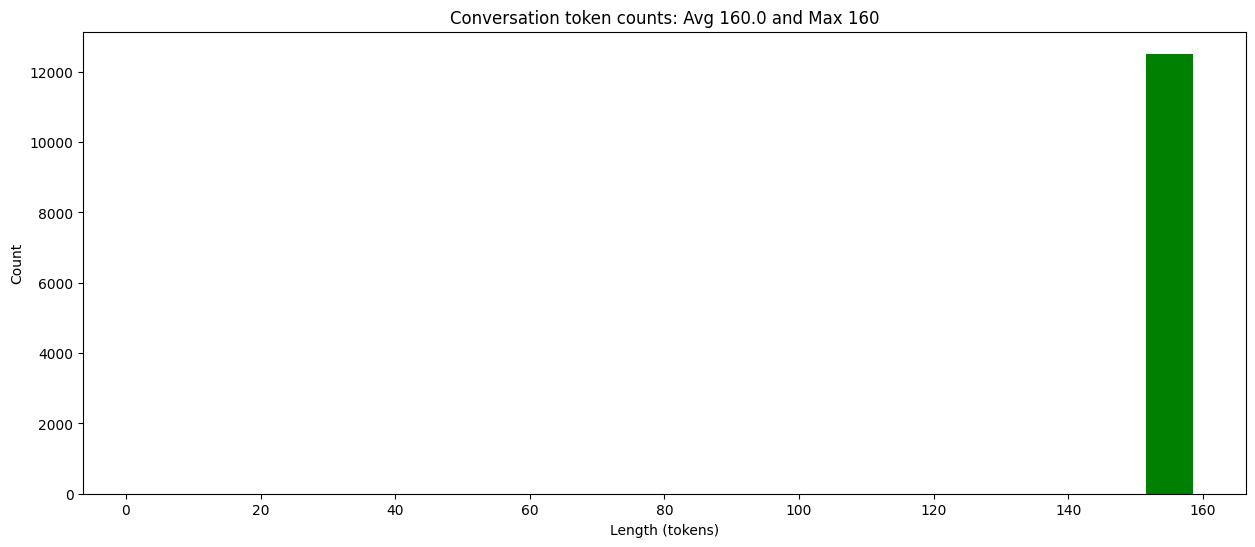

In [560]:
tokens = [item.token_count for item in conversation_items if item.include]

plt.figure(figsize=(15, 6))
plt.title(
    f"Conversation token counts: Avg {sum(tokens)/len(tokens):.1f} "
    f"and Max {max(tokens)}"
)
plt.xlabel("Length (tokens)")
plt.ylabel("Count")
plt.hist(tokens, rwidth=0.7, color="green", bins=range(0, max(tokens)+10, 10))
plt.show()

In [561]:
from ConversationLoad import load_conversations_from_rawdata

conversation_items = load_conversations_from_rawdata(rawdata,workers=8)
print(f'A grand total of {len(conversation_items):,} chars')

Loading conversations: 100%|██████████| 13/13 [00:08<00:00,  1.56it/s]


A grand total of 12,346 chars


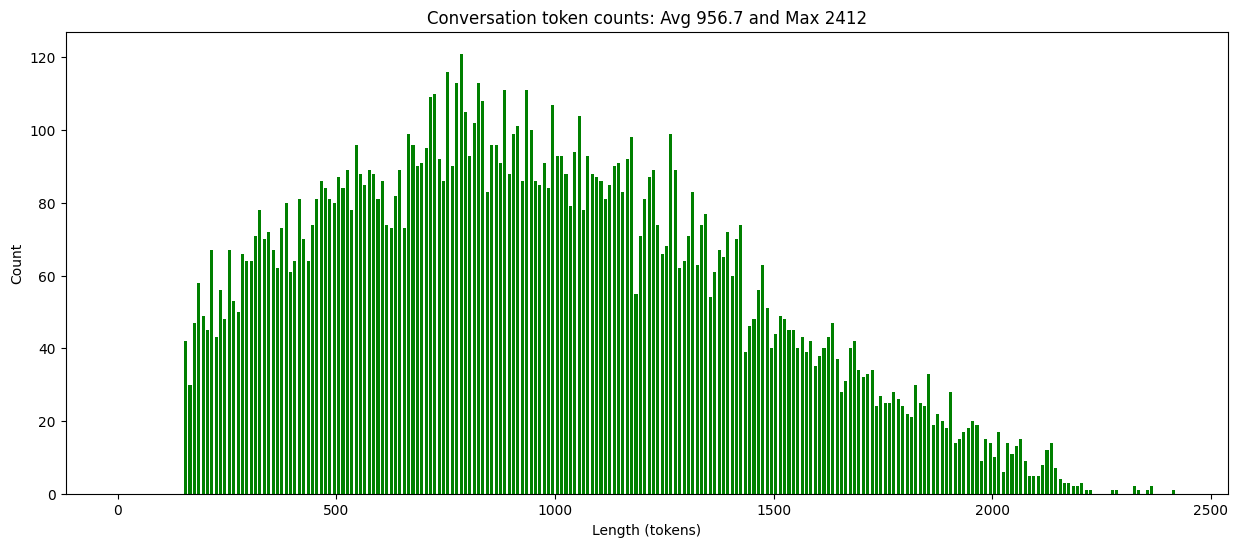

In [562]:
tokens = [item.token_count for item in conversation_items]

plt.figure(figsize=(15, 6))
plt.title(
    f"Conversation token counts: Avg {sum(tokens)/len(tokens):.1f} "
    f"and Max {max(tokens)}"
)
plt.xlabel("Length (tokens)")
plt.ylabel("Count")
plt.hist(tokens, rwidth=0.7, color="green", bins=range(0, max(tokens)+10, 10))
plt.show()

Kept 12346 convs (≤ 8000 chars). Avg=3424.6, Max=7980


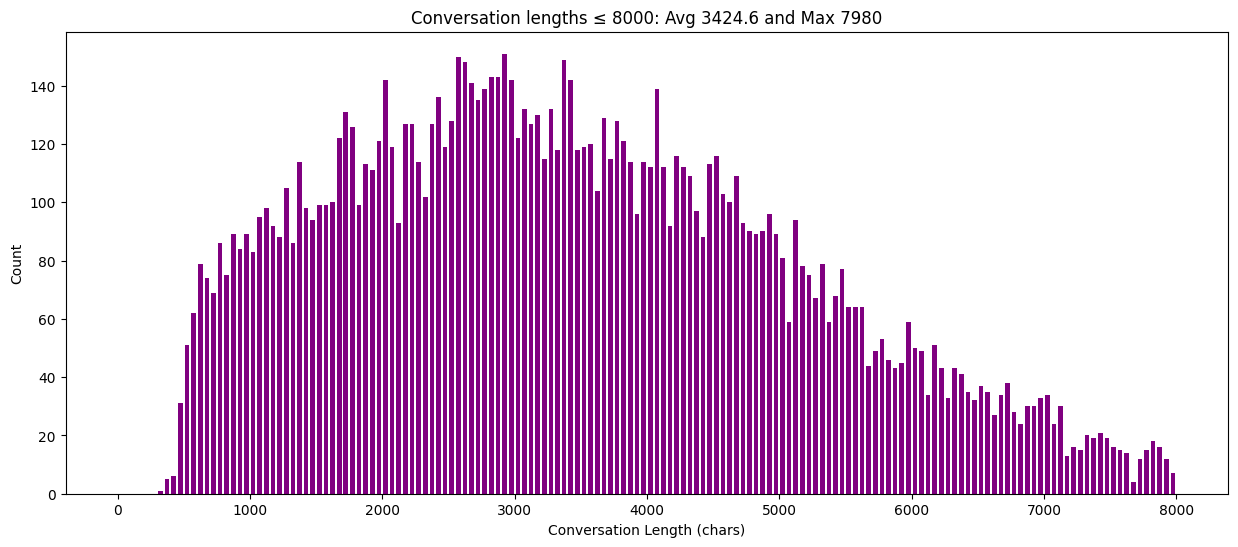

In [563]:
lengths = [it.length_chars for it in conversation_items if it.include]
print(f"Kept {len(lengths)} convs (≤ {MAX_CHARS} chars). "
      f"Avg={sum(lengths)/len(lengths):.1f}, Max={max(lengths)}")

plt.figure(figsize=(15, 6))
plt.title(f"Conversation lengths ≤ {MAX_CHARS}: "
          f"Avg {sum(lengths)/len(lengths):.1f} and Max {max(lengths)}")
plt.xlabel("Conversation Length (chars)")
plt.ylabel("Count")
plt.hist(lengths, rwidth=0.7, color="purple",
         bins=range(0, MAX_CHARS + 50, 50))
plt.show()


In [564]:
from collections import defaultdict
import numpy as np
import random

# Step 1: Create a dict để gom các hội thoại theo bucket độ dài (làm tròn bội số 100)
length_buckets = defaultdict(list)
for item in conversation_items:  # conversation_items = load_conversations_from_rawdata(ds)
    if not item.include:
        continue
    bucket_key = round(item.length_chars, -2)   # ví dụ 0, 100, 200, ...
    length_buckets[bucket_key].append(item)

# Step 2: Fix seed để reproducibility
np.random.seed(123)
random.seed(123)

# Step 3: Lấy mẫu từ mỗi bucket theo logic tương tự BookLoader
sample = []
for bucket_key in sorted(length_buckets.keys()):
    bucket = length_buckets[bucket_key]
    if bucket_key >= 800:             # nếu hội thoại dài (>= 800 chars) giữ hết
        sample.extend(bucket)
    elif len(bucket) <= 2000:         # nếu bucket nhỏ thì giữ hết
        sample.extend(bucket)
    else:                             # nếu bucket quá lớn thì random 2000
        idx = np.random.choice(len(bucket), size=2000, replace=False)
        sample.extend([bucket[i] for i in idx])

print(f"There are {len(sample):,} conversations in the sample")

There are 12,346 conversations in the sample


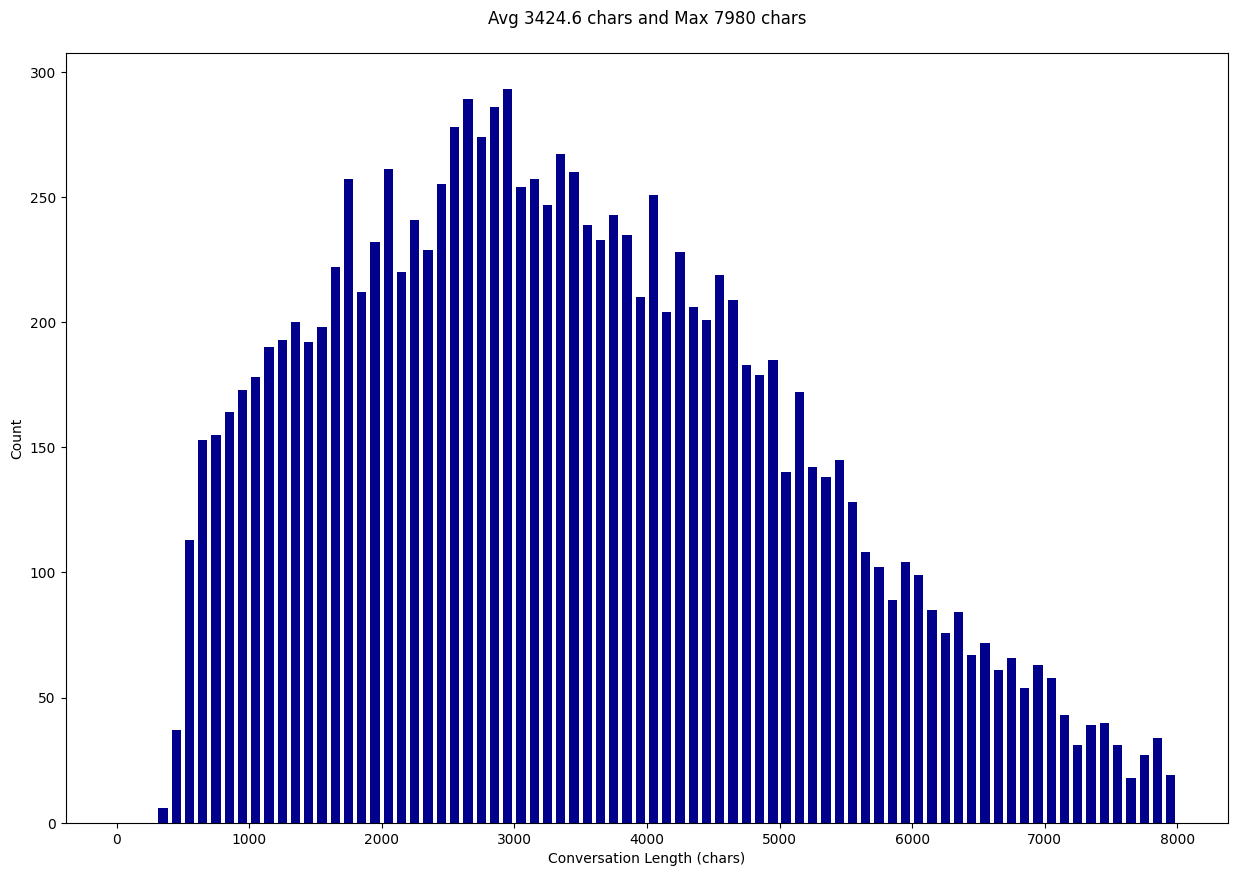

In [565]:
# Plot the distribution of conversation lengths in sample
lengths = [item.length_chars for item in sample if item.include]

plt.figure(figsize=(15, 10))
plt.title(f"Avg {sum(lengths)/len(lengths):.1f} chars and Max {max(lengths)} chars\n")
plt.xlabel('Conversation Length (chars)')
plt.ylabel('Count')

# bins cách nhau 100 ký tự
plt.hist(lengths, rwidth=0.7, color="darkblue", bins=range(0, max(lengths)+100, 100))
plt.show()


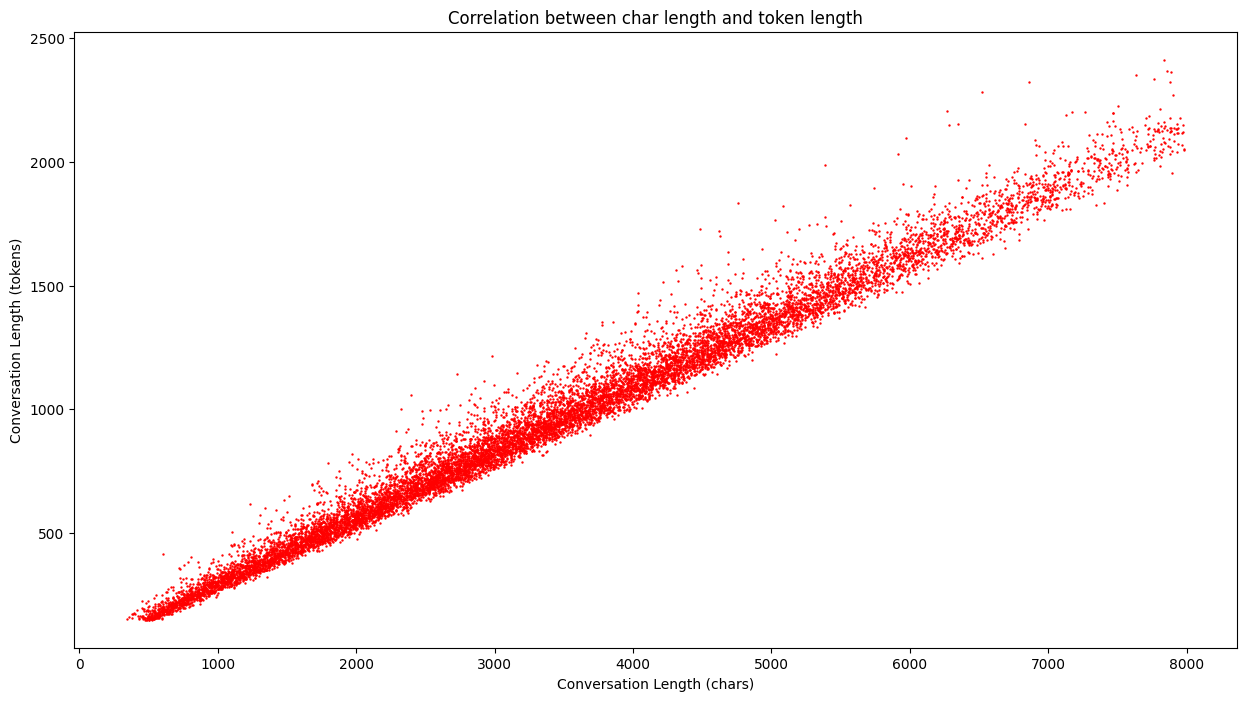

In [566]:
# How does the token count vary with the character length of the conversation?

lengths = [item.length_chars for item in sample if item.include]
tokens  = [item.token_count for item in sample if item.include]

plt.figure(figsize=(15, 8))
plt.scatter(lengths, tokens, s=0.5, color="red")

plt.xlabel('Conversation Length (chars)')
plt.ylabel('Conversation Length (tokens)')
plt.title('Correlation between char length and token length')

plt.show()


In [567]:
import random

# Cố định seed để tái lập kết quả
random.seed(123)

# Shuffle toàn bộ conversation_items
random.shuffle(conversation_items)

# Chia 90% train, 10% test
split_idx = int(0.9 * len(conversation_items))

train = conversation_items[:split_idx]
test  = conversation_items[split_idx:]

# In ra kết quả
print(f"Divided into a training set of {len(train):,} conversations "
      f"and a test set of {len(test):,} conversations")


Divided into a training set of 11,111 conversations and a test set of 1,235 conversations


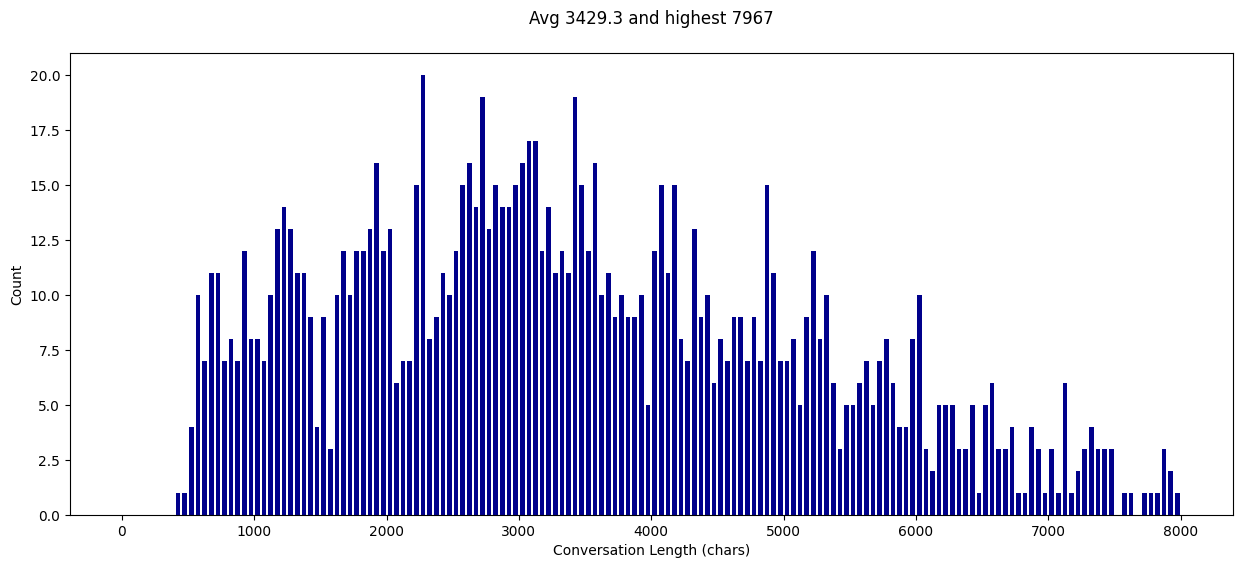

In [568]:
# Lấy độ dài ký tự của 2000 hội thoại test đầu tiên
lengths = [item.length_chars for item in test[:2000] if item.include]

plt.figure(figsize=(15, 6))
plt.title(f"Avg {sum(lengths)/len(lengths):.1f} and highest {max(lengths)}\n")
plt.xlabel('Conversation Length (chars)')
plt.ylabel('Count')
plt.hist(lengths, rwidth=0.7, color="darkblue", bins=range(0, max(lengths)+50, 50))
plt.show()


In [569]:
# Extract từ train và test
train_texts = [item.text for item in train if item.include]
train_lengths = [item.length_chars for item in train if item.include]

test_texts = [item.text for item in test if item.include]
test_lengths = [item.length_chars for item in test if item.include]

In [570]:
train_dataset = Dataset.from_dict({"text": train_texts, "length": train_lengths})
test_dataset = Dataset.from_dict({"text": test_texts, "length": test_lengths})

# Bundle
dataset = DatasetDict({
    "train": train_dataset,
    "test": test_dataset
})

In [571]:
# Upload lên Hugging Face Hub
HF_USER = "Fornight"
DATASET_NAME = f"{HF_USER}/conversation-data"

dataset.push_to_hub(DATASET_NAME, private=True)


Uploading the dataset shards: 100%|██████████| 1/1 [00:02<00:00,  2.93s/ shards]


CommitInfo(commit_url='https://huggingface.co/datasets/Fornight/conversation-data/commit/0b24f9f76f7ed972dc888d026e249f0a2f6febe6', commit_message='Upload dataset', commit_description='', oid='0b24f9f76f7ed972dc888d026e249f0a2f6febe6', pr_url=None, repo_url=RepoUrl('https://huggingface.co/datasets/Fornight/conversation-data', endpoint='https://huggingface.co', repo_type='dataset', repo_id='Fornight/conversation-data'), pr_revision=None, pr_num=None)

In [572]:
# write .pkl file for reuse
import pickle

with open('train.pkl', 'wb') as file:
    pickle.dump(train, file)

with open('test.pkl', 'wb') as file:
    pickle.dump(test, file)

In [573]:
# open .pkl files from local
import pickle

with open('train.pkl', 'rb') as file:
    train = pickle.load(file)

with open('test.pkl', 'rb') as file:
    test = pickle.load(file)